In [216]:
import pandas as pd
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression



In [217]:
# Load the movies_scaled_dummies.csv file from the data folder
movies_scaled = pd.read_csv('../data/movies_scaled_dummies.csv')
movies_scaled.head()

,Budget,Gross,Release Date,Runtime,Rating,Rating Count,Net Profit,ROI,MPAA Rating_G,MPAA Rating_PG,...,Genre_Family,Genre_Fantasy,Genre_History,Genre_Horror,Genre_Mystery,Genre_Romance,Genre_Science Fiction,Genre_Thriller,Genre_War,Genre_Western
0,-1.284438,296000000.0,10,-1.100607,-1.146270,-0.831512,288500000.0,38.466667,0,0,...,0,0,0,0,0,1,0,0,0,0
1,-1.284438,145793296.0,12,-0.832114,0.549913,-0.776143,138293296.0,18.439106,0,1,...,0,0,0,0,0,0,0,0,0,0
2,-1.191530,71079915.0,7,-0.787365,0.323756,-0.775063,58079915.0,4.467686,0,1,...,0,0,0,0,0,0,0,0,0,0
3,-1.174637,161001698.0,12,1.226329,0.323756,-0.775063,147001698.0,10.500121,0,0,...,0,0,0,0,0,0,0,0,1,0
4,-1.157745,84431625.0,4,-0.474124,0.662992,-0.742398,69431625.0,4.628775,0,1,...,0,0,0,0,0,0,0,0,0,0


In [218]:
# Split the data into 70% training and 30% testing sets
# We can't predict Gross with ROI or Net Profits so we will use all three as potential target variables

yfeatures = ['Gross','ROI','Net Profit']
X = movies_scaled.drop(yfeatures, axis=1)
y = movies_scaled[yfeatures]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

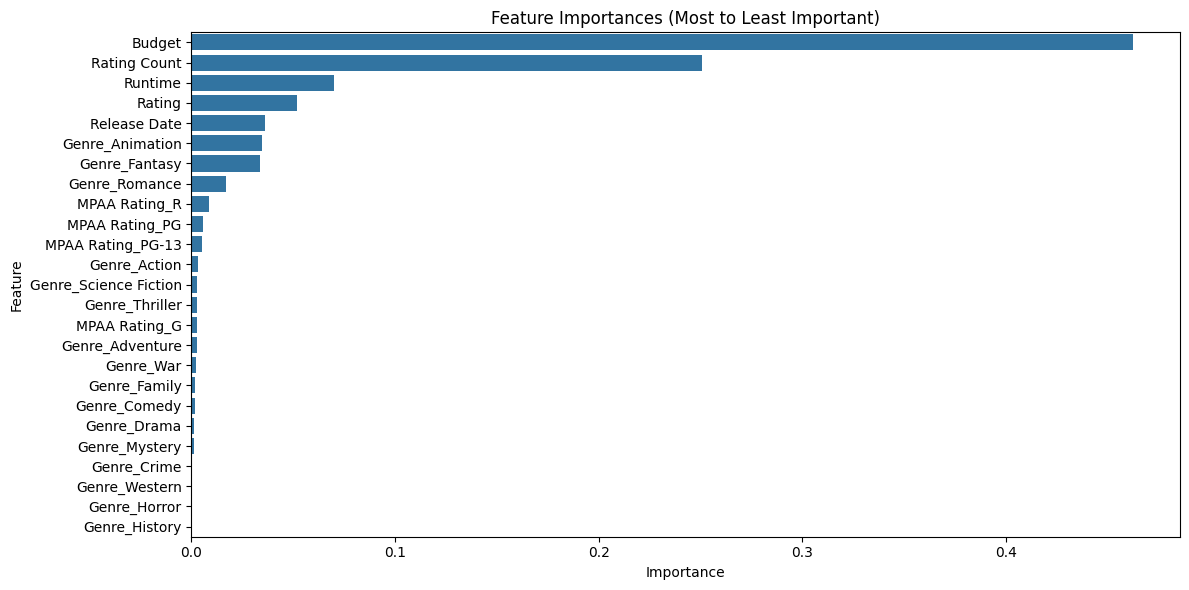

In [119]:

# Get feature importances from the best estimator after grid search
best_rf = grid_search.best_estimator_
importances = best_rf.feature_importances_
feature_names = X_train.columns

# Sort features by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices], y=np.array(feature_names)[indices])
plt.title('Feature Importances (Most to Least Important)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

This graph shows feature impoartance. The highest are Budget, Rating Count, Runtime, Rating, Release Date, Genre_Animation, Genre_Fantasy, and Genre_Romance.

In [ ]:
# Create and fit a Random Forest Regressor model on the training set
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
# Predict the gross, ROI, and Net Profit revenue on the test set
y_pred = rf.predict(X_test)

In [121]:
# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")


Mean Squared Error: 14139568466124118.0000
Mean Absolute Error: 71258143.4284
R^2 Score: 0.4972


Not The best model. Lets try it with just Gross as a prediction

In [122]:
yfeatures = ['Gross','ROI','Net Profit']
X = movies_scaled.drop(yfeatures, axis=1)
y = movies_scaled['Gross']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Create and fit a Random Forest Regressor model on the training set
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
# Predict the gross revenue on the test set
y_pred = rf.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

Mean Squared Error: 22340498018538380.0000
Mean Absolute Error: 109731416.2639
R^2 Score: 0.6073


In [123]:
yfeatures = ['Gross','ROI','Net Profit']
X = movies_scaled.drop(yfeatures, axis=1)
y = movies_scaled['ROI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Create and fit a Random Forest Regressor model on the training set
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
# Predict the ROI revenue on the test set
y_pred = rf.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

Mean Squared Error: 9.3155
Mean Absolute Error: 1.8879
R^2 Score: 0.6811


In [124]:
yfeatures = ['Gross','ROI','Net Profit']
X = movies_scaled.drop(yfeatures, axis=1)
y = movies_scaled['Net Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Create and fit a Random Forest Regressor model on the training set
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
# Predict the Net profit revenue on the test set
y_pred = rf.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

Mean Squared Error: 18871032728902960.0000
Mean Absolute Error: 101858808.0807
R^2 Score: 0.5362


Comparing the differnt calculations we can use for y features, ROI seems to have the best corrilation when using random forest. ROI can also be used to calculate the gross. So ROI will be used in the next tests.

In [240]:
# Remake the ROI test and train sets. using the most important features
features = [
    "Budget",
    "Rating Count",
    "Runtime",
    "Rating",
    "Release Date",
    "Genre_Animation",
    "Genre_Fantasy",
   ]


X = movies_scaled[features]
y = movies_scaled['ROI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [241]:
# Create and fit a Random Forest Regressor model on the training set
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
# Predict the ROI revenue on the test set
y_pred = rf.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

Mean Squared Error: 8.0981
Mean Absolute Error: 1.7632
R^2 Score: 0.7228


Using less features improved the model, Now we can see how Xboost compairs using the same features.

In [242]:
from xgboost import XGBRegressor

# Create and fit an XGBoost Regressor model on the training set
xgb = XGBRegressor(random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

# Predict the target variable on the test set
y_pred = xgb.predict(X_test)

# Calculate and print metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"XGBoost Mean Squared Error: {mse:.4f}")
print(f"XGBoost Mean Absolute Error: {mae:.4f}")
print(f"XGBoost R^2 : {r2:.4f}")

XGBoost Mean Squared Error: 9.5954
XGBoost Mean Absolute Error: 1.8490
XGBoost R^2 : 0.6715


XGBoost does not out preform random forest regression with an R squared of 0.72 vs 0.67

Lets go back to the random forest model and look at hyperparameters

In [174]:
# Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 20, 30, 40, 50, 60, 70],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 10],
}

# Initialize Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best R^2 score:", grid_search.best_score_)

Best parameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
Best R^2 score: 0.40365435961683405


Now we will try a linear regression model using only the linear variables

In [176]:


# Create and fit a Linear Regression model on the training set
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict the target variables on the test set
y_pred = lr.predict(X_test)

# Calculate and print metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression Mean Squared Error: {mse:.4f}")
print(f"Linear Regression Mean Absolute Error: {mae:.4f}")
print(f"Linear Regression R^2 Score: {r2:.4f}")

Linear Regression Mean Squared Error: 23.0219
Linear Regression Mean Absolute Error: 2.7704
Linear Regression R^2 Score: 0.2118


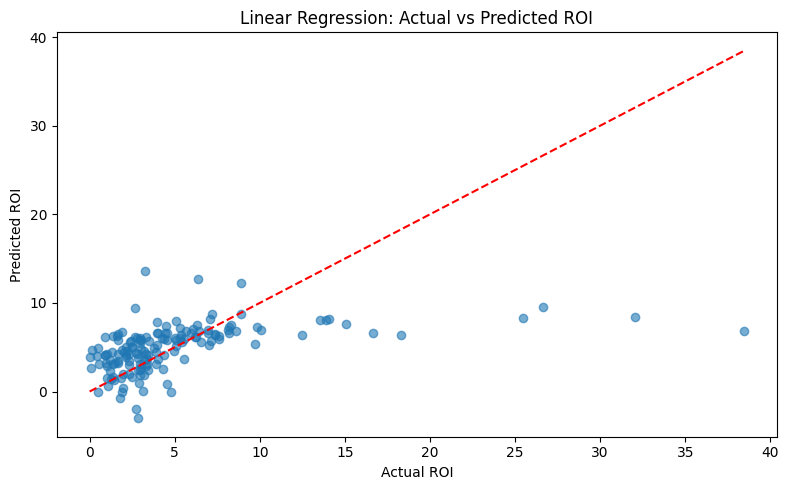

In [177]:
# Plot actual vs predicted values for the linear regression model
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual ROI")
plt.ylabel("Predicted ROI")
plt.title("Linear Regression: Actual vs Predicted ROI")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45-degree line
plt.tight_layout()
plt.show()

In [194]:
# Remake the ROI test and train sets. using the most important features
features = [
    "Budget",
    "Rating Count",
    "Runtime",
    "Rating",
    "Release Date"
    ]

X = movies_scaled[features]
y = movies_scaled['Gross']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [205]:


# Create and fit a Linear Regression model on the training set
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict the target variables on the test set
y_pred = lr.predict(X_test)

# Calculate and print metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression Mean Squared Error: {mse:.4f}")
print(f"Linear Regression Mean Absolute Error: {mae:.4f}")
print(f"Linear Regression R^2 Score: {r2:.4f}")

Linear Regression Mean Squared Error: 25497505384268168.0000
Linear Regression Mean Absolute Error: 117340642.2499
Linear Regression R^2 Score: 0.5518


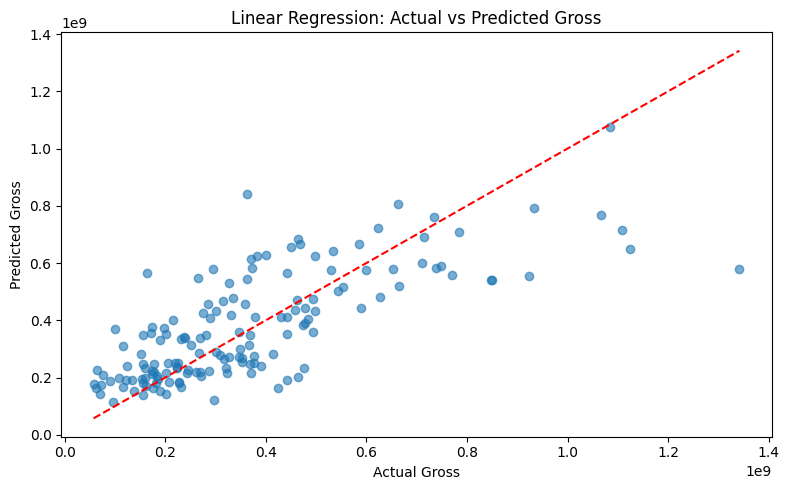

In [196]:
# Plot actual vs predicted values for the linear regression model
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Gross")
plt.ylabel("Predicted Gross")
plt.title("Linear Regression: Actual vs Predicted Gross")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45-degree line
plt.tight_layout()
plt.show()

The Linear regression predicting Gross preforms better the ROI. However compared to the Random Forest model, it has a R squared value of only .55 and a mean absolute error of 117 million. The random forest model should be used as a final model.